# 🧠 Therapeía — NLP Intent Classifier
## مقارنة بين CNN · LSTM · DistilBERT (Multilingual)

**الـ Intents الثمانية:**
| Intent | المعنى | أمثلة |
|--------|--------|-------|
| `wake`          | تفعيل الروبوت      | therapeia, يا ثيرابيا, wake up |
| `scan`          | التقاط وتحليل صورة | scan, امسح, identify this |
| `start`         | بدء التشغيل        | start, ابدأ, let's go |
| `stop`          | إيقاف كامل         | stop, وقف, halt |
| `sleep`         | وضع الخمول         | sleep mode, نام, standby |
| `inventory`     | عرض المخزون        | show all meds, الادوية الموجودة |
| `quantity`      | استعلام الكمية     | how many pills, كام باقي |
| `medicine_name` | معلومات دواء       | what is paracetamol, ايه هو الفلاجيل |

**Pipeline:**
```
Dataset 10K CSV → Preprocessing (AR+EN) → Encoding → CNN / BiLSTM / DistilBERT-Multilingual → Comparison → Pi Deployment
```


In [1]:
import subprocess, sys

pkgs = ['transformers', 'torch', 'scikit-learn', 'pandas',
        'numpy', 'matplotlib', 'seaborn', 'sentencepiece']
for p in pkgs:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', p], check=True)

print('All packages installed ✅')


All packages installed ✅


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, re, json, time, os
from collections import Counter

warnings.filterwarnings('ignore')
os.makedirs('figures', exist_ok=True)
os.makedirs('models', exist_ok=True)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score,
                             precision_score, recall_score)
from sklearn.feature_extraction.text import TfidfVectorizer

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_scheduler,
)
from torch.optim import AdamW

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')

# ── 8 distinct colors for 8 intents ──────────────────────────────────────────
PALETTE = ['#4CAF50','#2196F3','#FF9800','#E91E63',
           '#9C27B0','#00BCD4','#FF5722','#607D8B']


Device : cuda
PyTorch: 2.10.0+cu128


Shape  : (10000, 2)
Intents: ['inventory', 'medicine_name', 'quantity', 'scan', 'sleep', 'start', 'stop', 'wake']

intent
stop             1250
quantity         1250
inventory        1250
scan             1250
wake             1250
sleep            1250
medicine_name    1250
start            1250
Name: count, dtype: int64

                           text        intent
                   turn on asap          wake
                ممكن اقرأ الكود          scan
          capture image at once          scan
      hello robot are you there          wake
       عايز اعرف meloxicam الان medicine_name
                         go now         start
                 show all items     inventory
                 take a picture          scan
         get started right away         start
            attention right now          wake
يا روبوت لو سمحت صحى يا ثيرابيا          wake
                terapiya for me          wake


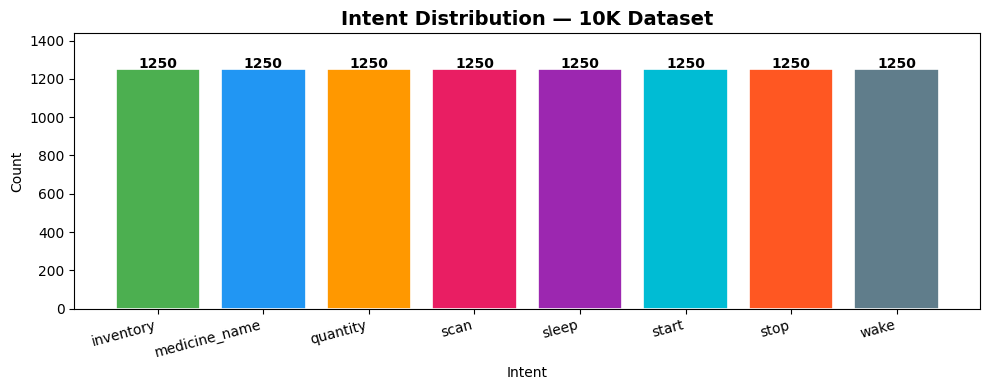

In [3]:
df = pd.read_csv('/content/therapeia_intent_dataset_10k.csv')

print(f'Shape  : {df.shape}')
print(f'Intents: {sorted(df.intent.unique())}')
print()
print(df.intent.value_counts())
print()
print(df.sample(12, random_state=1).to_string(index=False))

# ── Distribution bar chart ────────────────────────────────────────────────────
plt.figure(figsize=(10, 4))
counts = df.intent.value_counts().sort_index()
bars = plt.bar(counts.index, counts.values, color=PALETTE, edgecolor='white', linewidth=1.2)
for bar, v in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8, str(v),
             ha='center', fontweight='bold', fontsize=10)
plt.title('Intent Distribution — 10K Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Intent'); plt.ylabel('Count')
plt.xticks(rotation=15, ha='right')
plt.ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.savefig('figures/intent_distribution.png', dpi=150)
plt.show()


══════════════════════════════════════════════════
  Shape         : (10000, 2)
  Missing values: {'text': 0, 'intent': 0}
  Duplicates    : 0
══════════════════════════════════════════════════
  Arabic rows   : 3830  (38.3%)
  English rows  : 6464  (64.6%)
  Mixed rows    : 294
══════════════════════════════════════════════════


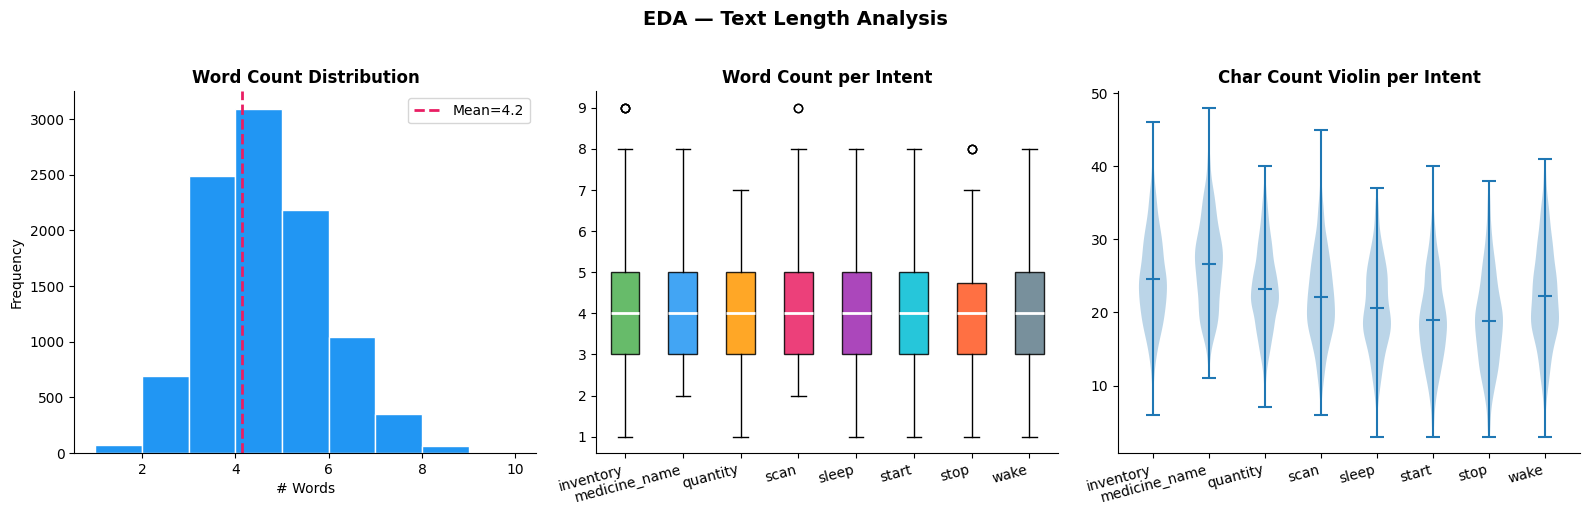

In [4]:
# ══════════════════════════════════════════════════════════
#  EDA — Exploratory Data Analysis
# ══════════════════════════════════════════════════════════

INTENT_COLORS = dict(zip(sorted(df['intent'].unique()), PALETTE))

# ── 1. Missing / duplicates ───────────────────────────────
print('═'*50)
print(f'  Shape         : {df.shape}')
print(f'  Missing values: {df.isnull().sum().to_dict()}')
print(f'  Duplicates    : {df.duplicated().sum()}')
print('═'*50)

# ── 2. Language distribution ──────────────────────────────
ar_mask = df['text'].str.contains('[ء-ي]', regex=True, na=False)
en_mask = df['text'].str.contains('[a-zA-Z]', regex=True, na=False)
print(f'  Arabic rows   : {ar_mask.sum()}  ({ar_mask.mean():.1%})')
print(f'  English rows  : {en_mask.sum()}  ({en_mask.mean():.1%})')
print(f'  Mixed rows    : {(ar_mask & en_mask).sum()}')
print('═'*50)

# ── 3. Text-length analysis ───────────────────────────────
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
df['char_count'] = df['text'].apply(len)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(df['word_count'], bins=range(1, df['word_count'].max()+2),
             color='#2196F3', edgecolor='white', linewidth=1)
axes[0].axvline(df['word_count'].mean(), color='#E91E63', linestyle='--',
                linewidth=2, label=f'Mean={df["word_count"].mean():.1f}')
axes[0].set_title('Word Count Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('# Words'); axes[0].set_ylabel('Frequency')
axes[0].legend(); axes[0].spines[['top','right']].set_visible(False)

intents_sorted = sorted(df['intent'].unique())
data_wc = [df[df['intent']==i]['word_count'].values for i in intents_sorted]
bp = axes[1].boxplot(data_wc, labels=intents_sorted, patch_artist=True,
                     medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color); patch.set_alpha(0.85)
axes[1].set_title('Word Count per Intent', fontsize=12, fontweight='bold')
axes[1].set_xticklabels(intents_sorted, rotation=15, ha='right')
axes[1].spines[['top','right']].set_visible(False)

axes[2].violinplot([df[df['intent']==i]['char_count'].values for i in intents_sorted],
                   showmeans=True)
axes[2].set_xticks(range(1, len(intents_sorted)+1))
axes[2].set_xticklabels(intents_sorted, rotation=15, ha='right')
axes[2].set_title('Char Count Violin per Intent', fontsize=12, fontweight='bold')
axes[2].spines[['top','right']].set_visible(False)

plt.suptitle('EDA — Text Length Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/eda_text_length.png', dpi=150, bbox_inches='tight')
plt.show()


In [5]:
# ══════════════════════════════════════════════════════════
#  Preprocessing — handles BOTH Arabic and English
# ══════════════════════════════════════════════════════════

def clean_text(text: str) -> str:
    text = str(text).strip()
    # keep Arabic (ء-ي), English (a-z), digits, and whitespace
    text = re.sub(r"[^a-z0-9\u0600-\u06FF\s]", ' ', text.lower())
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean'] = df['text'].apply(clean_text)

# Label encoding
le = LabelEncoder()
df['label'] = le.fit_transform(df['intent'])
INTENT_NAMES = list(le.classes_)
NUM_CLASSES  = len(INTENT_NAMES)
print('Intents :', INTENT_NAMES)
print('Num classes:', NUM_CLASSES)
print('Label map  :', dict(zip(INTENT_NAMES, le.transform(INTENT_NAMES).tolist())))

# ── Train 70 / Val 15 / Test 15 split ────────────────────
X_train, X_temp, y_train, y_temp = train_test_split(
    df['clean'].values, df['label'].values,
    test_size=0.30, stratify=df['label'], random_state=42)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

print(f'\nTrain: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')


Intents : ['inventory', 'medicine_name', 'quantity', 'scan', 'sleep', 'start', 'stop', 'wake']
Num classes: 8
Label map  : {'inventory': 0, 'medicine_name': 1, 'quantity': 2, 'scan': 3, 'sleep': 4, 'start': 5, 'stop': 6, 'wake': 7}

Train: 7000 | Val: 1500 | Test: 1500


In [6]:
# ══════════════════════════════════════════════════════════
#  Vocabulary (CNN / BiLSTM) — supports Arabic tokens
# ══════════════════════════════════════════════════════════

all_words = ' '.join(X_train).split()
vocab     = ['<PAD>', '<UNK>'] + sorted(set(all_words))
word2idx  = {w: i for i, w in enumerate(vocab)}
VOCAB_SIZE = len(vocab)
MAX_LEN    = 16   # increased for bilingual sentences

print(f'Vocab size : {VOCAB_SIZE:,}')
print(f'Max length : {MAX_LEN}')

def encode(texts, max_len=MAX_LEN):
    out = []
    for t in texts:
        ids = [word2idx.get(w, 1) for w in t.split()][:max_len]
        ids += [0] * (max_len - len(ids))
        out.append(ids)
    return np.array(out, dtype=np.int64)

X_train_enc = encode(X_train)
X_val_enc   = encode(X_val)
X_test_enc  = encode(X_test)

print('Encoded shape (train):', X_train_enc.shape)


Vocab size : 503
Max length : 16
Encoded shape (train): (7000, 16)


In [7]:
class IntentDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):            return len(self.y)
    def __getitem__(self, i):     return self.X[i], self.y[i]

BATCH = 32   # larger batch for 10K dataset

train_dl = DataLoader(IntentDataset(X_train_enc, y_train), batch_size=BATCH, shuffle=True,  num_workers=0)
val_dl   = DataLoader(IntentDataset(X_val_enc,   y_val),   batch_size=BATCH, num_workers=0)
test_dl  = DataLoader(IntentDataset(X_test_enc,  y_test),  batch_size=BATCH, num_workers=0)

print(f'Train batches: {len(train_dl)} | Val: {len(val_dl)} | Test: {len(test_dl)}')


Train batches: 219 | Val: 47 | Test: 47


In [8]:
# ══════════════════════════════════════════════════════════
#  Model 1 — TextCNN
# ══════════════════════════════════════════════════════════

class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, num_classes=NUM_CLASSES,
                 num_filters=128, kernel_sizes=(2, 3, 4, 5)):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, k) for k in kernel_sizes
        ])
        self.dropout = nn.Dropout(0.4)
        self.bn      = nn.BatchNorm1d(num_filters * len(kernel_sizes))
        self.fc      = nn.Linear(num_filters * len(kernel_sizes), num_classes)

    def forward(self, x):
        x = self.embedding(x).permute(0, 2, 1)          # (B, E, L)
        pooled = [torch.relu(conv(x)).max(dim=2)[0]
                  for conv in self.convs]
        x = torch.cat(pooled, dim=1)                     # (B, filters*4)
        x = self.bn(x)
        return self.fc(self.dropout(x))

cnn_model = TextCNN(VOCAB_SIZE).to(DEVICE)
total = sum(p.numel() for p in cnn_model.parameters())
print(f'TextCNN parameters: {total:,}')
print(cnn_model)


TextCNN parameters: 299,400
TextCNN(
  (embedding): Embedding(503, 128, padding_idx=0)
  (convs): ModuleList(
    (0): Conv1d(128, 128, kernel_size=(2,), stride=(1,))
    (1): Conv1d(128, 128, kernel_size=(3,), stride=(1,))
    (2): Conv1d(128, 128, kernel_size=(4,), stride=(1,))
    (3): Conv1d(128, 128, kernel_size=(5,), stride=(1,))
  )
  (dropout): Dropout(p=0.4, inplace=False)
  (bn): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc): Linear(in_features=512, out_features=8, bias=True)
)


In [9]:
# ══════════════════════════════════════════════════════════
#  Model 2 — BiLSTM with Attention
# ══════════════════════════════════════════════════════════

class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim * 2, 1)

    def forward(self, lstm_out):
        # lstm_out: (B, L, H*2)
        scores  = self.attn(lstm_out).squeeze(-1)        # (B, L)
        weights = torch.softmax(scores, dim=1).unsqueeze(2)  # (B, L, 1)
        context = (lstm_out * weights).sum(dim=1)        # (B, H*2)
        return context


class BiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden=128,
                 num_layers=2, num_classes=NUM_CLASSES):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden, num_layers=num_layers,
                            batch_first=True, bidirectional=True, dropout=0.3)
        self.attention = Attention(hidden)
        self.dropout   = nn.Dropout(0.4)
        self.fc        = nn.Linear(hidden * 2, num_classes)

    def forward(self, x):
        x         = self.embedding(x)
        out, _    = self.lstm(x)           # (B, L, H*2)
        context   = self.attention(out)    # (B, H*2) — attention pooling
        return self.fc(self.dropout(context))

lstm_model = BiLSTM(VOCAB_SIZE).to(DEVICE)
total = sum(p.numel() for p in lstm_model.parameters())
print(f'BiLSTM parameters: {total:,}')
print(lstm_model)


BiLSTM parameters: 726,153
BiLSTM(
  (embedding): Embedding(503, 128, padding_idx=0)
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attention): Attention(
    (attn): Linear(in_features=256, out_features=1, bias=True)
  )
  (dropout): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=256, out_features=8, bias=True)
)


In [10]:
# ══════════════════════════════════════════════════════════
#  Training & Evaluation Utilities
# ══════════════════════════════════════════════════════════

def train_model(model, train_dl, val_dl, epochs=30, lr=1e-3, name='Model'):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    history   = {k: [] for k in ('train_loss','val_loss','train_acc','val_acc')}

    best_val_acc = 0.0
    best_state   = None

    for epoch in range(epochs):
        # ── Train ──────────────────────────────────────────
        model.train()
        t_loss = t_correct = 0
        for X_b, y_b in train_dl:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            optimizer.zero_grad()
            out  = model(X_b)
            loss = criterion(out, y_b)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            t_loss    += loss.item()
            t_correct += (out.argmax(1) == y_b).sum().item()
        scheduler.step()

        # ── Val ────────────────────────────────────────────
        model.eval()
        v_loss = v_correct = 0
        with torch.no_grad():
            for X_b, y_b in val_dl:
                X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
                out    = model(X_b)
                v_loss += criterion(out, y_b).item()
                v_correct += (out.argmax(1) == y_b).sum().item()

        ta = t_correct / len(train_dl.dataset)
        va = v_correct / len(val_dl.dataset)
        history['train_loss'].append(t_loss / len(train_dl))
        history['val_loss'].append(v_loss  / len(val_dl))
        history['train_acc'].append(ta)
        history['val_acc'].append(va)

        # Best-model checkpoint
        if va > best_val_acc:
            best_val_acc = va
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if (epoch + 1) % 5 == 0:
            print(f'[{name}] Epoch {epoch+1:02d}/{epochs} | '
                  f'Loss {t_loss/len(train_dl):.3f} | '
                  f'Train {ta:.2%} | Val {va:.2%}')

    # Restore best weights
    model.load_state_dict(best_state)
    print(f'[{name}] Best val acc: {best_val_acc:.2%}  ✅')
    return history


def get_preds_true(model, dataloader):
    """Collect predictions & ground truth for a standard (X, y) dataloader."""
    model.eval()
    all_p, all_t = [], []
    with torch.no_grad():
        for X_b, y_b in dataloader:
            all_p.extend(model(X_b.to(DEVICE)).argmax(1).cpu().numpy())
            all_t.extend(y_b.numpy())
    return np.array(all_p), np.array(all_t)


def evaluate(model, test_dl, name='Model', cmap='Blues'):
    preds, true = get_preds_true(model, test_dl)
    acc = accuracy_score(true, preds)

    print(f'\n── {name}  Test Accuracy: {acc:.2%} ──')
    print(classification_report(true, preds, target_names=INTENT_NAMES, digits=4))

    cm = confusion_matrix(true, preds)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=INTENT_NAMES, yticklabels=INTENT_NAMES,
                linewidths=0.5, linecolor='white')
    plt.title(f'{name} — Confusion Matrix  ({acc:.2%})', fontweight='bold')
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.xticks(rotation=20, ha='right'); plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f'figures/cm_{name.lower().replace(" ","_")}.png', dpi=150)
    plt.show()
    return acc, preds, true

print('Utilities ready ✅')


Utilities ready ✅


⏳ Training TextCNN...
[TextCNN] Epoch 05/35 | Loss 0.319 | Train 99.41% | Val 98.93%
[TextCNN] Epoch 10/35 | Loss 0.299 | Train 99.49% | Val 99.07%
[TextCNN] Epoch 15/35 | Loss 0.294 | Train 99.47% | Val 99.07%
[TextCNN] Epoch 20/35 | Loss 0.290 | Train 99.53% | Val 99.00%
[TextCNN] Epoch 25/35 | Loss 0.286 | Train 99.71% | Val 99.07%
[TextCNN] Epoch 30/35 | Loss 0.284 | Train 99.61% | Val 99.00%
[TextCNN] Epoch 35/35 | Loss 0.283 | Train 99.67% | Val 99.00%
[TextCNN] Best val acc: 99.27%  ✅
Finished in 78.1s

── TextCNN  Test Accuracy: 99.20% ──
               precision    recall  f1-score   support

    inventory     1.0000    1.0000    1.0000       187
medicine_name     1.0000    1.0000    1.0000       187
     quantity     1.0000    1.0000    1.0000       188
         scan     1.0000    1.0000    1.0000       188
        sleep     1.0000    1.0000    1.0000       188
        start     0.9888    0.9465    0.9672       187
         stop     1.0000    1.0000    1.0000       188
      

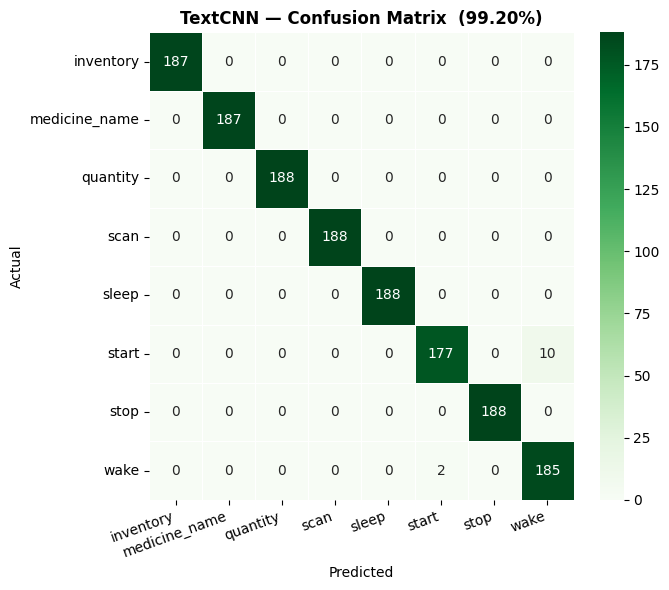

In [11]:
print('⏳ Training TextCNN...')
t0 = time.time()
cnn_history = train_model(cnn_model, train_dl, val_dl, epochs=35, name='TextCNN')
print(f'Finished in {time.time()-t0:.1f}s')
cnn_acc, cnn_preds, cnn_true = evaluate(cnn_model, test_dl, name='TextCNN', cmap='Greens')


⏳ Training BiLSTM...
[BiLSTM] Epoch 05/35 | Loss 0.286 | Train 99.27% | Val 99.13%
[BiLSTM] Epoch 10/35 | Loss 0.287 | Train 99.30% | Val 98.93%
[BiLSTM] Epoch 15/35 | Loss 0.277 | Train 99.50% | Val 98.87%
[BiLSTM] Epoch 20/35 | Loss 0.276 | Train 99.57% | Val 99.07%
[BiLSTM] Epoch 25/35 | Loss 0.274 | Train 99.64% | Val 98.93%
[BiLSTM] Epoch 30/35 | Loss 0.274 | Train 99.69% | Val 98.93%
[BiLSTM] Epoch 35/35 | Loss 0.273 | Train 99.71% | Val 98.93%
[BiLSTM] Best val acc: 99.27%  ✅
Finished in 45.7s

── BiLSTM  Test Accuracy: 99.07% ──
               precision    recall  f1-score   support

    inventory     1.0000    1.0000    1.0000       187
medicine_name     1.0000    1.0000    1.0000       187
     quantity     1.0000    1.0000    1.0000       188
         scan     1.0000    1.0000    1.0000       188
        sleep     1.0000    1.0000    1.0000       188
        start     0.9730    0.9626    0.9677       187
         stop     0.9895    1.0000    0.9947       188
         wake   

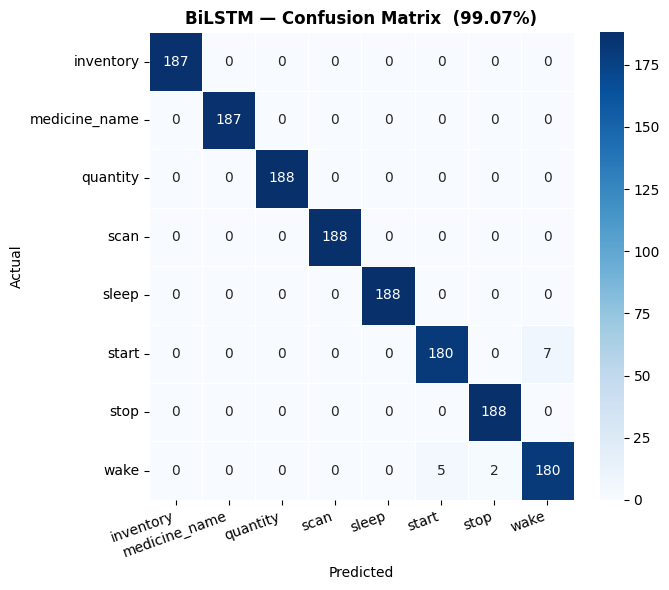

In [12]:
print('⏳ Training BiLSTM...')
t0 = time.time()
lstm_history = train_model(lstm_model, train_dl, val_dl, epochs=35, name='BiLSTM')
print(f'Finished in {time.time()-t0:.1f}s')
lstm_acc, lstm_preds, lstm_true = evaluate(lstm_model, test_dl, name='BiLSTM', cmap='Blues')


In [13]:
# ══════════════════════════════════════════════════════════
#  Model 3 — DistilBERT Multilingual (AR + EN support)
#  'distilbert-base-multilingual-cased' handles both Arabic
#  and English — much better than 'uncased' for bilingual data
# ══════════════════════════════════════════════════════════

BERT_MODEL = 'distilbert-base-multilingual-cased'
tokenizer  = AutoTokenizer.from_pretrained(BERT_MODEL)

class BertIntentDataset(Dataset):
    def __init__(self, texts, labels, max_len=32):
        self.enc    = tokenizer(list(texts), truncation=True,
                                padding='max_length', max_length=max_len,
                                return_tensors='pt')
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):  return len(self.labels)

    def __getitem__(self, i):
        return {k: v[i] for k, v in self.enc.items()}, self.labels[i]

BERT_BATCH = 32
bert_train_dl = DataLoader(BertIntentDataset(X_train, y_train),
                           batch_size=BERT_BATCH, shuffle=True,  num_workers=0)
bert_val_dl   = DataLoader(BertIntentDataset(X_val,   y_val),
                           batch_size=BERT_BATCH, num_workers=0)
bert_test_dl  = DataLoader(BertIntentDataset(X_test,  y_test),
                           batch_size=BERT_BATCH, num_workers=0)

bert_model = AutoModelForSequenceClassification.from_pretrained(
    BERT_MODEL, num_labels=NUM_CLASSES).to(DEVICE)

total = sum(p.numel() for p in bert_model.parameters())
print(f'DistilBERT-Multilingual parameters: {total:,}')
print('Model ready ✅')


config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/542M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT-Multilingual parameters: 135,330,824
Model ready ✅


⏳ Training DistilBERT-Multilingual...
[DistilBERT] Epoch 1/7 | Loss 1.503 | Train 50.81% | Val 95.33%
[DistilBERT] Epoch 2/7 | Loss 0.337 | Train 97.86% | Val 99.20%
[DistilBERT] Epoch 3/7 | Loss 0.284 | Train 99.19% | Val 98.87%
[DistilBERT] Epoch 4/7 | Loss 0.280 | Train 99.40% | Val 99.07%
[DistilBERT] Epoch 5/7 | Loss 0.278 | Train 99.46% | Val 99.07%
[DistilBERT] Epoch 6/7 | Loss 0.277 | Train 99.50% | Val 99.00%
[DistilBERT] Epoch 7/7 | Loss 0.275 | Train 99.63% | Val 99.00%
[DistilBERT] Best val acc: 99.20%  ✅
Finished in 210.9s

── DistilBERT-Multilingual  Test Accuracy: 99.33% ──
               precision    recall  f1-score   support

    inventory     1.0000    1.0000    1.0000       187
medicine_name     1.0000    1.0000    1.0000       187
     quantity     1.0000    1.0000    1.0000       188
         scan     1.0000    1.0000    1.0000       188
        sleep     0.9947    1.0000    0.9973       188
        start     1.0000    0.9465    0.9725       187
         stop     

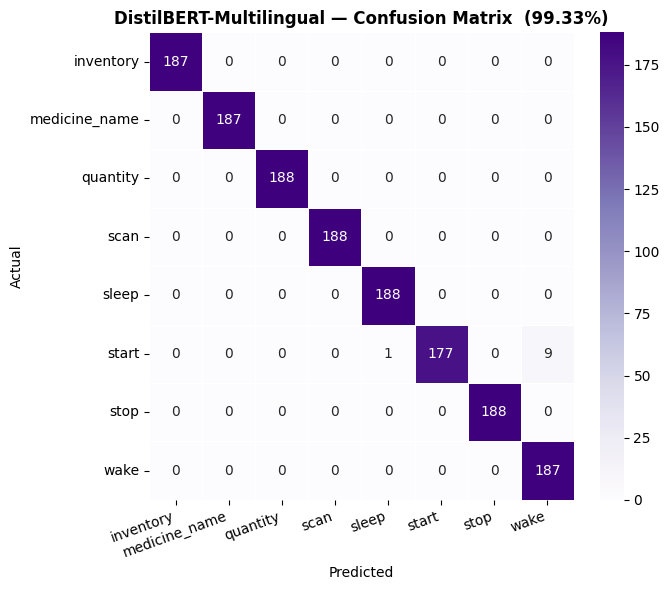

In [14]:
def train_bert(model, train_dl, val_dl, epochs=6, lr=2e-5, name='DistilBERT'):
    optimizer    = AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    total_steps  = len(train_dl) * epochs
    scheduler    = get_scheduler('cosine', optimizer,
                                 num_warmup_steps=int(total_steps * 0.1),
                                 num_training_steps=total_steps)
    criterion    = nn.CrossEntropyLoss(label_smoothing=0.05)
    history      = {k: [] for k in ('train_loss','val_loss','train_acc','val_acc')}

    best_val_acc = 0.0
    best_state   = None

    for epoch in range(epochs):
        model.train()
        t_loss = t_correct = 0
        for batch, labels in train_dl:
            batch  = {k: v.to(DEVICE) for k, v in batch.items()}
            labels = labels.to(DEVICE)
            optimizer.zero_grad()
            out  = model(**batch).logits
            loss = criterion(out, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            t_loss    += loss.item()
            t_correct += (out.argmax(1) == labels).sum().item()

        model.eval()
        v_loss = v_correct = 0
        with torch.no_grad():
            for batch, labels in val_dl:
                batch  = {k: v.to(DEVICE) for k, v in batch.items()}
                labels = labels.to(DEVICE)
                out    = model(**batch).logits
                v_loss    += criterion(out, labels).item()
                v_correct += (out.argmax(1) == labels).sum().item()

        ta = t_correct / len(train_dl.dataset)
        va = v_correct / len(val_dl.dataset)
        history['train_acc'].append(ta);  history['val_acc'].append(va)
        history['train_loss'].append(t_loss / len(train_dl))
        history['val_loss'].append(v_loss   / len(val_dl))

        if va > best_val_acc:
            best_val_acc = va
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        print(f'[{name}] Epoch {epoch+1}/{epochs} | '
              f'Loss {t_loss/len(train_dl):.3f} | '
              f'Train {ta:.2%} | Val {va:.2%}')

    model.load_state_dict(best_state)
    print(f'[{name}] Best val acc: {best_val_acc:.2%}  ✅')
    return history


def get_bert_preds_true(model, dataloader):
    model.eval()
    all_p, all_t = [], []
    with torch.no_grad():
        for batch, labels in dataloader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            all_p.extend(model(**batch).logits.argmax(1).cpu().numpy())
            all_t.extend(labels.numpy())
    return np.array(all_p), np.array(all_t)


def evaluate_bert(model, test_dl, name='DistilBERT-Multilingual', cmap='Purples'):
    preds, true = get_bert_preds_true(model, test_dl)
    acc = accuracy_score(true, preds)

    print(f'\n── {name}  Test Accuracy: {acc:.2%} ──')
    print(classification_report(true, preds, target_names=INTENT_NAMES, digits=4))

    cm = confusion_matrix(true, preds)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=INTENT_NAMES, yticklabels=INTENT_NAMES,
                linewidths=0.5, linecolor='white')
    plt.title(f'{name} — Confusion Matrix  ({acc:.2%})', fontweight='bold')
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.xticks(rotation=20, ha='right'); plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f'figures/cm_distilbert.png', dpi=150)
    plt.show()
    return acc, preds, true


print('⏳ Training DistilBERT-Multilingual...')
t0 = time.time()
bert_history = train_bert(bert_model, bert_train_dl, bert_val_dl, epochs=7)
print(f'Finished in {time.time()-t0:.1f}s')
bert_acc, bert_preds, bert_true = evaluate_bert(bert_model, bert_test_dl)


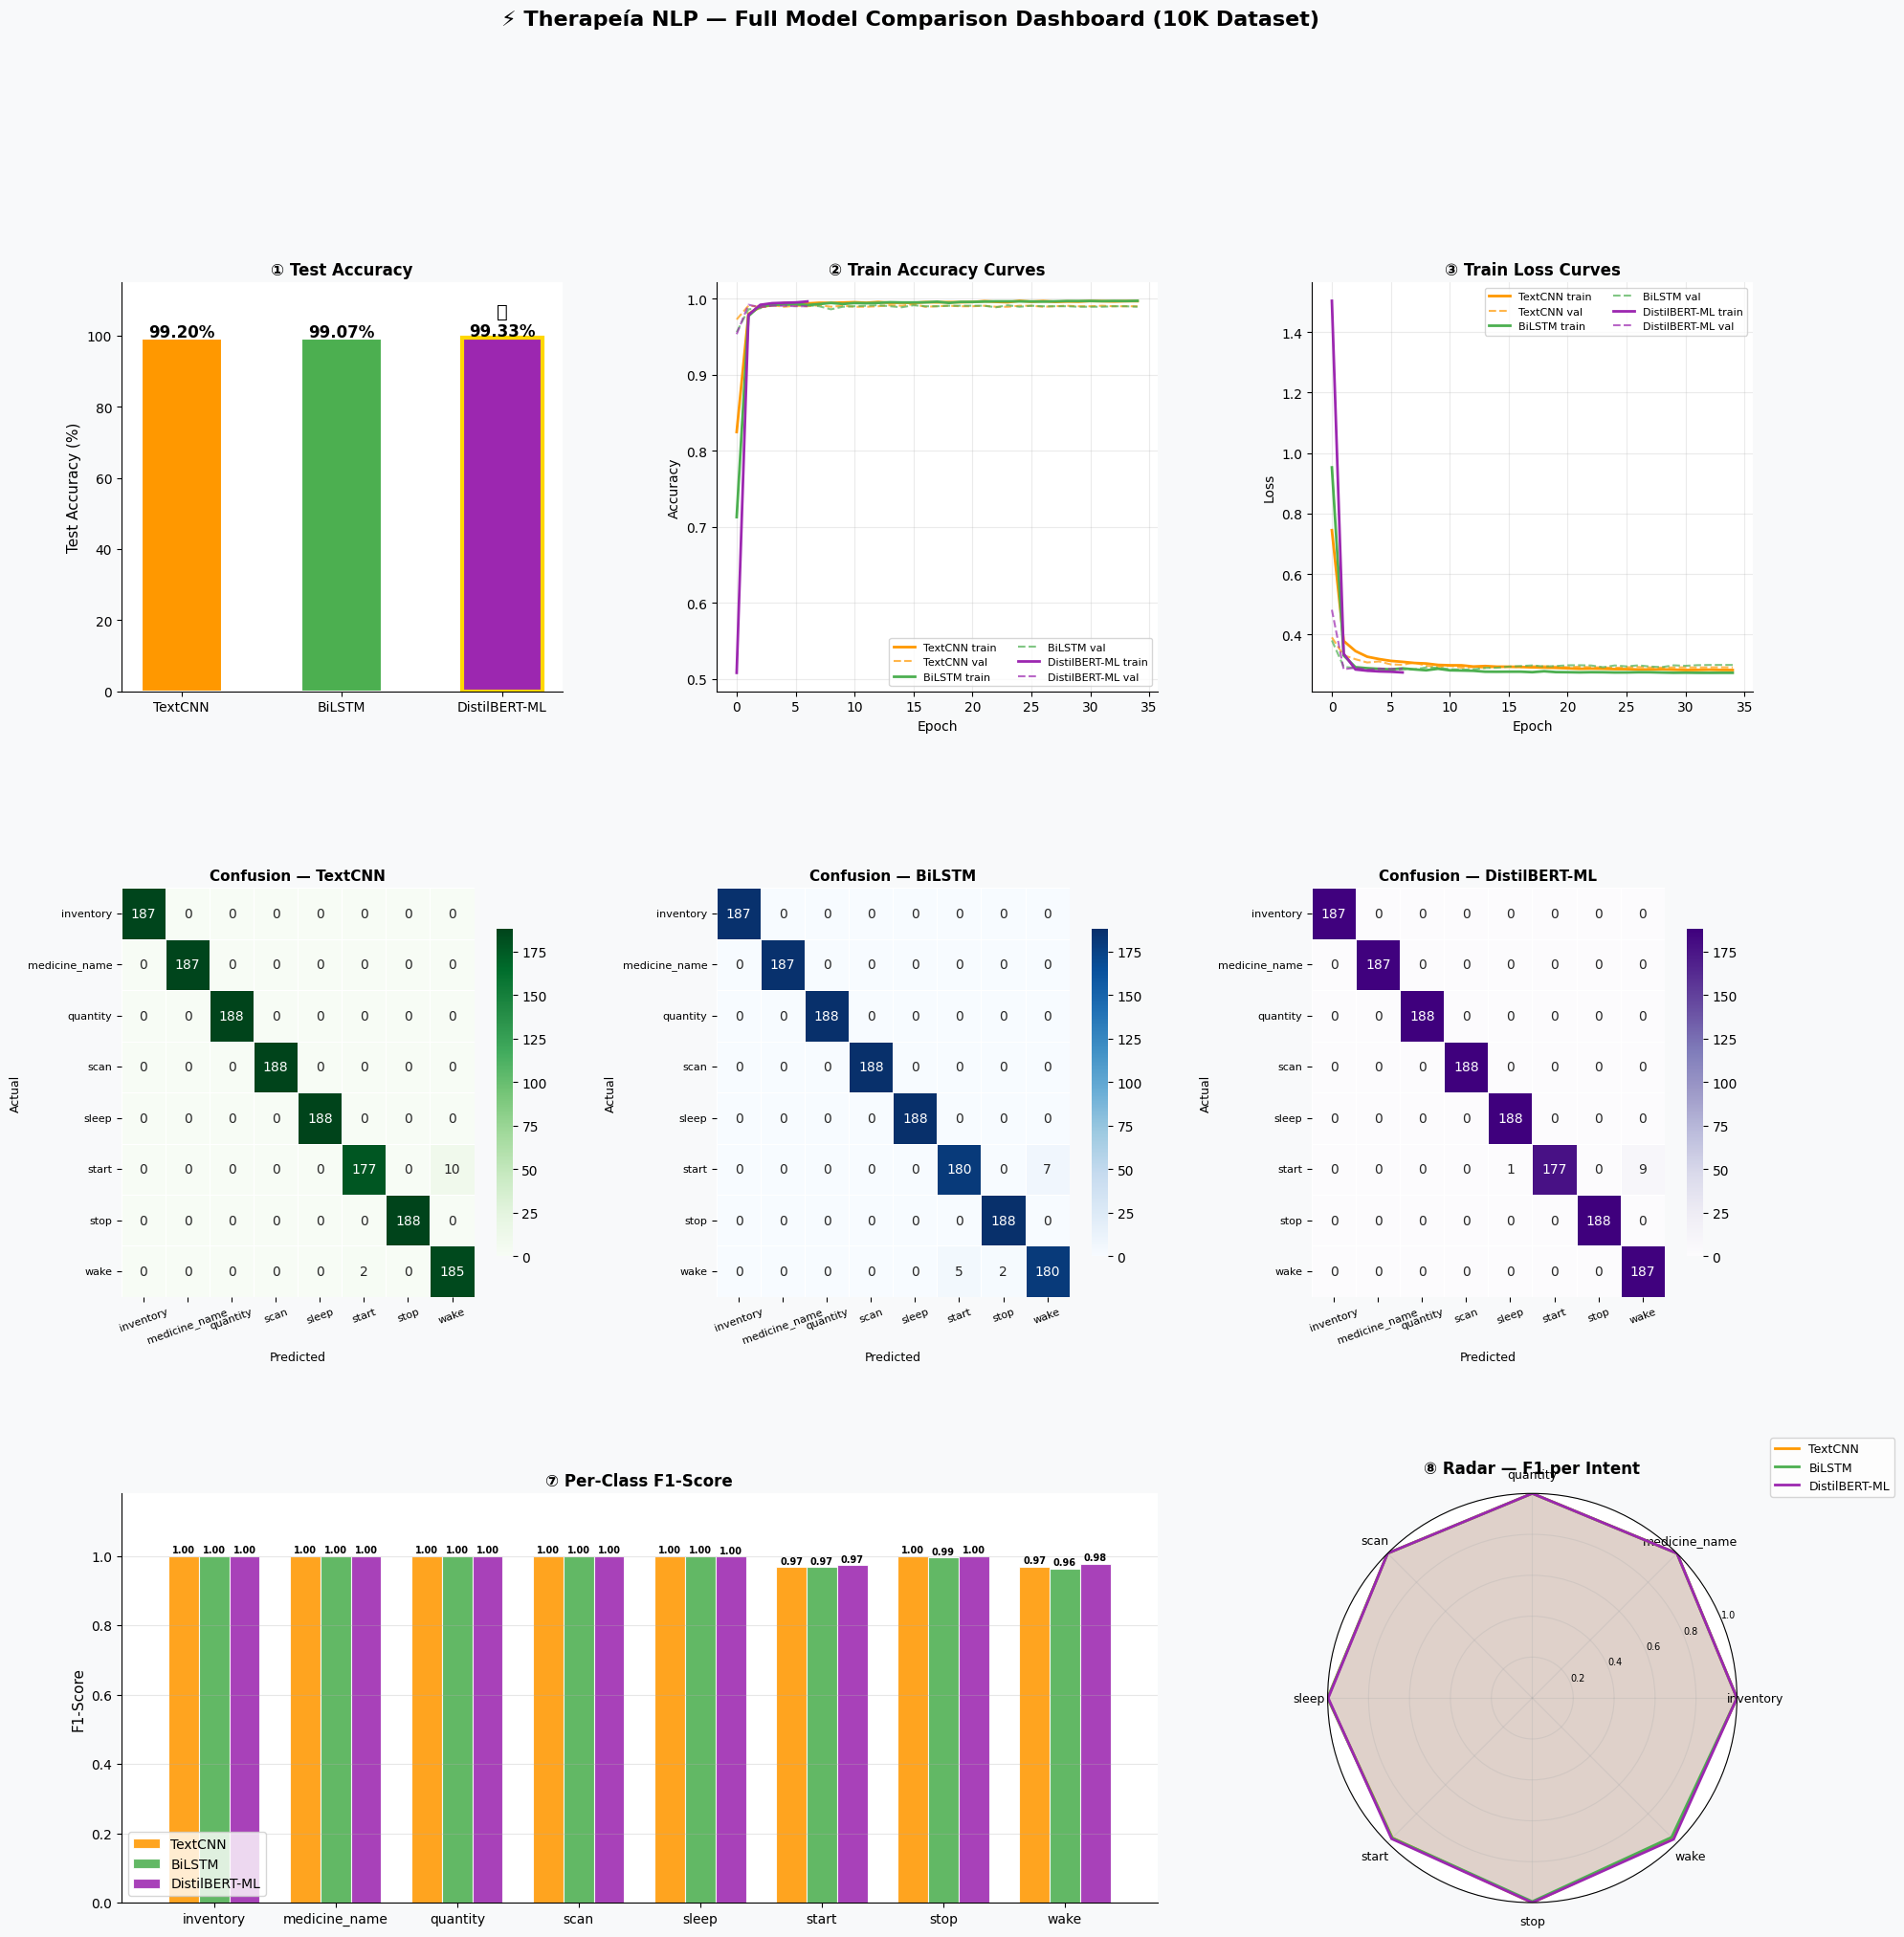

✅ Dashboard saved


In [15]:
# ══════════════════════════════════════════════════════════
#  Full Model Comparison Dashboard — 8 sub-plots
# ══════════════════════════════════════════════════════════

model_names = ['TextCNN', 'BiLSTM', 'DistilBERT-ML']
accuracies  = [cnn_acc, lstm_acc, bert_acc]
histories   = [cnn_history, lstm_history, bert_history]
preds_list  = [cnn_preds,  lstm_preds,  bert_preds]
true_list   = [cnn_true,   lstm_true,   bert_true]
COLORS3     = ['#FF9800', '#4CAF50', '#9C27B0']

fig = plt.figure(figsize=(22, 22))
fig.patch.set_facecolor('#f8f9fa')
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.48, wspace=0.35)

# ① Accuracy Bar ──────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(model_names, [a*100 for a in accuracies],
               color=COLORS3, width=0.5, edgecolor='white', linewidth=1.5)
for bar, acc in zip(bars, accuracies):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'{acc:.2%}', ha='center', fontweight='bold', fontsize=12)
ax1.set_ylim(0, 115); ax1.set_ylabel('Test Accuracy (%)', fontsize=11)
ax1.set_title('① Test Accuracy', fontweight='bold', fontsize=12)
ax1.spines[['top','right']].set_visible(False)
best_idx = accuracies.index(max(accuracies))
ax1.patches[best_idx].set_edgecolor('#FFD700')
ax1.patches[best_idx].set_linewidth(3)
ax1.text(best_idx, accuracies[best_idx]*100 + 6, '🏆', ha='center', fontsize=14)

# ② Training Accuracy Curves ──────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
for name, hist, color in zip(model_names, histories, COLORS3):
    ax2.plot(hist['train_acc'], label=f'{name} train', color=color, lw=2)
    ax2.plot(hist['val_acc'],   label=f'{name} val',   color=color, lw=1.5,
             linestyle='--', alpha=0.7)
ax2.set_title('② Train Accuracy Curves', fontweight='bold', fontsize=12)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.legend(fontsize=8, ncol=2); ax2.grid(alpha=0.25)
ax2.spines[['top','right']].set_visible(False)

# ③ Training Loss Curves ──────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
for name, hist, color in zip(model_names, histories, COLORS3):
    ax3.plot(hist['train_loss'], label=f'{name} train', color=color, lw=2)
    ax3.plot(hist['val_loss'],   label=f'{name} val',   color=color, lw=1.5,
             linestyle='--', alpha=0.7)
ax3.set_title('③ Train Loss Curves', fontweight='bold', fontsize=12)
ax3.set_xlabel('Epoch'); ax3.set_ylabel('Loss')
ax3.legend(fontsize=8, ncol=2); ax3.grid(alpha=0.25)
ax3.spines[['top','right']].set_visible(False)

# ④⑤⑥ Confusion Matrices ─────────────────────────────────
cmaps_ = ['Greens', 'Blues', 'Purples']
for col, (name, p, t, cmap) in enumerate(zip(model_names, preds_list, true_list, cmaps_)):
    ax = fig.add_subplot(gs[1, col])
    cm = confusion_matrix(t, p)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=INTENT_NAMES, yticklabels=INTENT_NAMES,
                linewidths=0.4, linecolor='white', ax=ax,
                cbar_kws={'shrink': 0.8})
    ax.set_title(f'Confusion — {name}', fontweight='bold', fontsize=11)
    ax.set_xlabel('Predicted', fontsize=9); ax.set_ylabel('Actual', fontsize=9)
    ax.tick_params(axis='x', labelsize=8, rotation=20)
    ax.tick_params(axis='y', labelsize=8, rotation=0)

# ⑦ Per-class F1 Grouped Bar ──────────────────────────────
ax7 = fig.add_subplot(gs[2, :2])
x   = np.arange(len(INTENT_NAMES))
w   = 0.25
f1s = [f1_score(t, p, average=None) for p, t in zip(preds_list, true_list)]

for i, (name, f1, color) in enumerate(zip(model_names, f1s, COLORS3)):
    ax7.bar(x + (i-1)*w, f1, w, label=name, color=color, alpha=0.88,
            edgecolor='white', linewidth=0.8)
    for j, v in enumerate(f1):
        ax7.text(x[j]+(i-1)*w, v+0.01, f'{v:.2f}',
                 ha='center', fontsize=7, fontweight='bold')

ax7.set_xticks(x); ax7.set_xticklabels(INTENT_NAMES, fontsize=10)
ax7.set_ylim(0, 1.18); ax7.set_ylabel('F1-Score', fontsize=11)
ax7.set_title('⑦ Per-Class F1-Score', fontweight='bold', fontsize=12)
ax7.legend(fontsize=10); ax7.grid(axis='y', alpha=0.3)
ax7.spines[['top','right']].set_visible(False)

# ⑧ Radar Chart ───────────────────────────────────────────
ax8 = fig.add_subplot(gs[2, 2], polar=True)
angles = np.linspace(0, 2*np.pi, len(INTENT_NAMES), endpoint=False).tolist()
angles += angles[:1]

for name, f1, color in zip(model_names, f1s, COLORS3):
    values = list(f1) + [f1[0]]
    ax8.plot(angles, values, color=color, lw=2, label=name)
    ax8.fill(angles, values, color=color, alpha=0.12)

ax8.set_xticks(angles[:-1])
ax8.set_xticklabels(INTENT_NAMES, size=9)
ax8.set_ylim(0, 1)
ax8.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax8.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], size=7)
ax8.set_title('⑧ Radar — F1 per Intent', fontweight='bold', fontsize=12, pad=15)
ax8.legend(loc='upper right', bbox_to_anchor=(1.4, 1.15), fontsize=9)
ax8.grid(alpha=0.3)

plt.suptitle('⚡ Therapeía NLP — Full Model Comparison Dashboard (10K Dataset)',
             fontsize=16, fontweight='bold', y=1.01)
plt.savefig('figures/full_comparison_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='#f8f9fa')
plt.show()
print('✅ Dashboard saved')


In [16]:
summary_rows = []
for name, p, t in zip(model_names, preds_list, true_list):
    summary_rows.append({
        'Model'    : name,
        'Accuracy' : f'{accuracy_score(t, p):.4f}',
        'Macro-F1' : f'{f1_score(t, p, average="macro"):.4f}',
        'Precision': f'{precision_score(t, p, average="macro"):.4f}',
        'Recall'   : f'{recall_score(t, p, average="macro"):.4f}',
    })

summary_df = pd.DataFrame(summary_rows).set_index('Model')

print('\n' + '═'*60)
print('   🏆  FINAL LEADERBOARD — Therapeía NLP  (10K dataset)')
print('═'*60)
print(summary_df.to_string())
print('═'*60)

best_model = summary_df['Accuracy'].astype(float).idxmax()
print(f'\n  🥇  Best Model (accuracy) : {best_model}')
print(f'  💡  Pi-friendly (speed)   : TextCNN  (fastest inference, no tokenizer download)')
print('═'*60)



════════════════════════════════════════════════════════════
   🏆  FINAL LEADERBOARD — Therapeía NLP  (10K dataset)
════════════════════════════════════════════════════════════
              Accuracy Macro-F1 Precision  Recall
Model                                            
TextCNN         0.9920   0.9920    0.9922  0.9920
BiLSTM          0.9907   0.9906    0.9906  0.9906
DistilBERT-ML   0.9933   0.9933    0.9936  0.9933
════════════════════════════════════════════════════════════

  🥇  Best Model (accuracy) : DistilBERT-ML
  💡  Pi-friendly (speed)   : TextCNN  (fastest inference, no tokenizer download)
════════════════════════════════════════════════════════════


In [17]:
# ══════════════════════════════════════════════════════════
#  Save all models
# ══════════════════════════════════════════════════════════

meta = {
    'word2idx'    : word2idx,
    'intent_names': INTENT_NAMES,
    'max_len'     : MAX_LEN,
    'num_classes' : NUM_CLASSES,
}
with open('models/nlp_meta.json', 'w', encoding='utf-8') as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

torch.save(cnn_model.state_dict(),  'models/intent_cnn.pt')
torch.save(lstm_model.state_dict(), 'models/intent_lstm.pt')
bert_model.save_pretrained('models/intent_bert')
tokenizer.save_pretrained('models/intent_bert')

print('All models saved ✅')
print()
print('📦 Deployment guide:')
print('  models/intent_cnn.pt    — TextCNN   (fastest on Pi, ~1ms/inference)')
print('  models/intent_lstm.pt   — BiLSTM    (balanced speed/accuracy)')
print('  models/intent_bert/     — DistilBERT-ML (best accuracy, needs ~200MB RAM)')


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

All models saved ✅

📦 Deployment guide:
  models/intent_cnn.pt    — TextCNN   (fastest on Pi, ~1ms/inference)
  models/intent_lstm.pt   — BiLSTM    (balanced speed/accuracy)
  models/intent_bert/     — DistilBERT-ML (best accuracy, needs ~200MB RAM)


In [20]:
# ══════════════════════════════════════════════════════════
#  Pi Inference — replaces all keyword-matching functions
# ══════════════════════════════════════════════════════════

def load_intent_model(model_type: str = 'cnn'):
    """Load a saved model for inference on Raspberry Pi."""
    with open('models/nlp_meta.json', encoding='utf-8') as f:
        meta = json.load(f)

    w2i    = meta['word2idx']
    labels = meta['intent_names']
    mlen   = meta['max_len']
    nclass = meta['num_classes']

    if model_type == 'cnn':
        m = TextCNN(len(w2i), num_classes=nclass)
        m.load_state_dict(torch.load('models/intent_cnn.pt', map_location='cpu'))
    elif model_type == 'lstm':
        m = BiLSTM(len(w2i), num_classes=nclass)
        m.load_state_dict(torch.load('models/intent_lstm.pt', map_location='cpu'))
    else:
        raise ValueError(f'Unknown model_type: {model_type}. Use cnn or lstm.')

    m.eval()
    return m, w2i, labels, mlen


def clean_input(text: str) -> str:
    """Same preprocessing as training (AR + EN)."""
    text = str(text).strip().lower()
    text = re.sub(r'[^a-z0-9\u0600-\u06FF\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()


def predict_intent(text: str, model, word2idx: dict,
                   intent_names: list, max_len: int = 16,
                   threshold: float = 0.50):
    """
    Predict intent for a text (Arabic or English).
    Returns: (intent_str, confidence_float)
    Falls back to 'unknown' if confidence < threshold.

    Replaces: is_start() / is_stop() / is_sleep() / is_scan() / ...
    """
    clean = clean_input(text)
    ids   = [word2idx.get(w, 1) for w in clean.split()][:max_len]
    ids  += [0] * (max_len - len(ids))
    x     = torch.tensor([ids], dtype=torch.long)

    with torch.no_grad():
        probs = torch.softmax(model(x), dim=1)[0]

    conf, idx = probs.max(0)
    conf = conf.item()
    return (intent_names[idx.item()], conf) if conf >= threshold else ('unknown', conf)


# ── Quick test ────────────────────────────────────────────
pi_model, pi_w2i, pi_labels, pi_mlen = load_intent_model('cnn')

test_phrases = [
    ('hey therapeia wake up',        'wake'),
    ('يا ثيرابيا',                   'wake'),
    ('start scanning',               'start'),
    ('ابدأ دلوقتي',                  'start'),
    ('scan the medicine',            'scan'),
    ('امسح الباركود',                'scan'),
    ('show all medicines',           'inventory'),
    ('ممكن كل الادوية',             'inventory'),
    ('how many tablets left',        'quantity'),
    ('كام باقي',                     'quantity'),
    ('what is paracetamol',          'medicine_name'),
    ('ايه هو الميتفورمين',           'medicine_name'),
    ('stop everything',              'stop'),
    ('وقف يا ثيرابيا',              'stop'),
    ('sleep mode please',            'sleep'),
    ('ادخل وضع الانتظار',           'sleep'),
    ('خبطت لنيل الرفيع',            'unknown?'),  # gibberish
]

print(f"{'Input':<35} {'Predicted':<14} {'Conf':<7} {'Expected'}")
print('─' * 75)
for phrase, expected in test_phrases:
    intent, conf = predict_intent(phrase, pi_model, pi_w2i, pi_labels, max_len=pi_mlen)
    mark = '✅' if intent == expected or expected == 'unknown?' else '❌'
    print(f'{phrase:<35} {intent:<14} {conf:>5.1%}  {expected}  {mark}')

Input                               Predicted      Conf    Expected
───────────────────────────────────────────────────────────────────────────
hey therapeia wake up               wake           98.3%  wake  ✅
يا ثيرابيا                          wake           84.3%  wake  ✅
start scanning                      start          97.2%  start  ✅
ابدأ دلوقتي                         start          93.5%  start  ✅
scan the medicine                   scan           97.1%  scan  ✅
امسح الباركود                       scan           95.2%  scan  ✅
show all medicines                  inventory      97.7%  inventory  ✅
ممكن كل الادوية                     inventory      96.9%  inventory  ✅
how many tablets left               quantity       97.7%  quantity  ✅
كام باقي                            quantity       96.6%  quantity  ✅
what is paracetamol                 medicine_name  93.7%  medicine_name  ✅
ايه هو الميتفورمين                  medicine_name  88.6%  medicine_name  ✅
stop everything           